In [1]:
import numpy as np
from enum import IntEnum
from typing import Dict, Any
from ray.rllib.algorithms.ppo import PPOConfig
from ray.tune.logger import UnifiedLogger
from ray.tune.registry import register_env
from ray.rllib.env import EnvContext
from ray.rllib.utils.annotations import override as ray_override
import gymnasium as gym
import os
import shutil
from ray.rllib.algorithms.algorithm import Algorithm

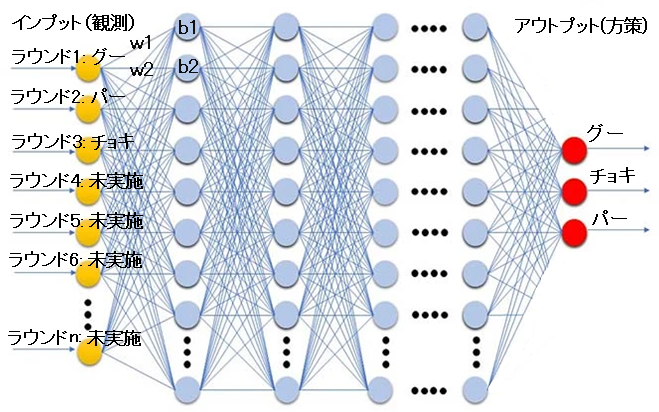

In [2]:
class RockPaperScissorsEnum(IntEnum):
    """じゃんけんの手を表す列挙型"""

    ROCK = 0
    PAPER = 1
    SCISSORS = 2


class FightResultEnum(IntEnum):
    """じゃんけんの結果を表す列挙型"""

    WIN = 0
    LOSE = 1
    DRAW = 2


def get_rock_paper_scissors_result(
    my_hand: RockPaperScissorsEnum, enemy_hand: RockPaperScissorsEnum
) -> FightResultEnum:
    """じゃんけんの結果を判定する関数.

    Args:
        my_hand (RockPaperScissorsEnum): 自分の手
        enemy_hand (RockPaperScissorsEnum): 相手の手

    Returns:
        FightResultEnum: じゃんけんの結果
    """
    if my_hand == enemy_hand:
        # 引き分け
        return FightResultEnum.DRAW
    elif (
        (
            my_hand == RockPaperScissorsEnum.ROCK
            and enemy_hand == RockPaperScissorsEnum.SCISSORS
        )
        or (
            my_hand == RockPaperScissorsEnum.PAPER
            and enemy_hand == RockPaperScissorsEnum.ROCK
        )
        or (
            my_hand == RockPaperScissorsEnum.SCISSORS
            and enemy_hand == RockPaperScissorsEnum.PAPER
        )
    ):
        # 勝ち
        return FightResultEnum.WIN
    else:
        # 負け
        return FightResultEnum.LOSE


class PetternRockPaperScissorsHandMaker:
    """パターンに基づいてじゃんけんの手を生成するクラス."""

    def __init__(self, pattern: list[RockPaperScissorsEnum]):
        self.pattern = pattern
        self.index = 0

    def __call__(self) -> RockPaperScissorsEnum:
        hand = self.pattern[self.index]
        self.index = (self.index + 1) % len(self.pattern)
        return hand

In [3]:
pattern = [
    RockPaperScissorsEnum.ROCK,
    RockPaperScissorsEnum.PAPER,
    RockPaperScissorsEnum.ROCK,
    RockPaperScissorsEnum.SCISSORS,
    RockPaperScissorsEnum.PAPER,
    RockPaperScissorsEnum.SCISSORS,
    RockPaperScissorsEnum.ROCK,
    RockPaperScissorsEnum.SCISSORS,
    RockPaperScissorsEnum.PAPER,
]

enemy_hand_maker = PetternRockPaperScissorsHandMaker(pattern=pattern)

for i in range(30):
    print(enemy_hand_maker())

len(pattern)

RockPaperScissorsEnum.ROCK
RockPaperScissorsEnum.PAPER
RockPaperScissorsEnum.ROCK
RockPaperScissorsEnum.SCISSORS
RockPaperScissorsEnum.PAPER
RockPaperScissorsEnum.SCISSORS
RockPaperScissorsEnum.ROCK
RockPaperScissorsEnum.SCISSORS
RockPaperScissorsEnum.PAPER
RockPaperScissorsEnum.ROCK
RockPaperScissorsEnum.PAPER
RockPaperScissorsEnum.ROCK
RockPaperScissorsEnum.SCISSORS
RockPaperScissorsEnum.PAPER
RockPaperScissorsEnum.SCISSORS
RockPaperScissorsEnum.ROCK
RockPaperScissorsEnum.SCISSORS
RockPaperScissorsEnum.PAPER
RockPaperScissorsEnum.ROCK
RockPaperScissorsEnum.PAPER
RockPaperScissorsEnum.ROCK
RockPaperScissorsEnum.SCISSORS
RockPaperScissorsEnum.PAPER
RockPaperScissorsEnum.SCISSORS
RockPaperScissorsEnum.ROCK
RockPaperScissorsEnum.SCISSORS
RockPaperScissorsEnum.PAPER
RockPaperScissorsEnum.ROCK
RockPaperScissorsEnum.PAPER
RockPaperScissorsEnum.ROCK


9

In [4]:
class RockPaperScissorsEnv(gym.Env):
    """じゃんけん環境.

    AIは複数回のじゃんけんを行い、相手の手は確率的に決定される.
    """

    def __init__(self, config: EnvContext):
        super().__init__()
        self.config = config

        # じゃんけんの回数を取得
        self.num_play = config.get("round_num", 0)
        assert self.num_play, "round_num must be greater than 0"

        # じゃんけんの相手側（非AI）を初期化
        self.enemy_hand_maker = config.get("enemy_hand_maker", enemy_hand_maker)

        # 観測空間を定義
        enemy_hands = gym.spaces.Box(  # 各ラウンドの相手の手を観測する空間
            low=-1,
            high=2,
            shape=(self.num_play,),
            dtype=np.int32,
        )
        fight_result = gym.spaces.Discrete(3)  # 勝ち, 負け, 引き分けを観測する空間
        self.observation_space = gym.spaces.Tuple((enemy_hands, fight_result))

        # 行動空間を定義
        self.action_space = gym.spaces.Discrete(
            3
        )  # じゃんけんの手（0: グー, 1: パー, 2: チョキ）

    @ray_override(gym.Env)
    def reset(self, **kargs) -> tuple[np.ndarray | tuple, Dict[str, Any]]:
        """環境をリセットする.

        Returns:
            tuple: (観測, その他情報)
        """
        self.step_num = 0

        # 初回の観測: [-1, -1, -1, ...] (num_play回分)
        self.enemy_hand_obs = np.ones((self.num_play,), dtype=int) * -1

        # 初回は引き分け
        obs = (self.enemy_hand_obs, FightResultEnum.DRAW.value)
        return obs, {}

    @ray_override(gym.Env)
    def step(
        self, action: int
    ) -> tuple[np.ndarray | tuple, float, bool, bool, Dict[str, Any]]:
        """環境を1ステップ進める.

        Args:
            action (int): AIの手（0: グー, 1: パー, 2: チョキ）

        Returns:
            tuple: (観測, 報酬, 終了フラグ, 強制終了フラグ, その他情報)
        """
        # じゃんけんを行う
        self.step_num += 1
        my_hand = RockPaperScissorsEnum(action)
        enemy_hand = self.enemy_hand_maker()
        fight_result = get_rock_paper_scissors_result(my_hand, enemy_hand)

        # 勝敗に基づいて報酬を設定
        if fight_result == FightResultEnum.WIN:
            reward = 1.0
        elif fight_result == FightResultEnum.LOSE:
            reward = -1.0
        else:
            reward = 0.0

        # self.num_play 回のじゃんけんを行ったら終了
        done = self.step_num == self.num_play

        # 相手の一連の手を観測: [2, 0, 1, 1, 2, -1, ..] (num_play回分)
        self.enemy_hand_obs[self.step_num - 1] = enemy_hand.value
        obs = (self.enemy_hand_obs, fight_result.value)
        return obs, reward, done, False, {}


register_env("rock-paper-scissors", lambda config: RockPaperScissorsEnv(config=config))

## obs time-line example

| round |  |  |  |  |  | fight_resut |
| :--: | :--: | :--: | :--: | :--: | :--: | :--: |
| 0 | -1 | -1 | -1 | -1 | -1 | 0
| 1 | 2 | -1 | -1 | -1 | -1 | 1
| 2 | 2 | 0 | -1 | -1 | -1 | 0
| 3 | 2 | 0 | 1 | -1 | -1 | 2
| 4 | 2 | 0 | 1 | 0 | -1 | 1
| 5 | 2 | 0 | 1 | 0 | 1 | 2

In [5]:
# 学習結果保存用ディレクトリの作成
log_dir = "logs"
if os.path.exists(log_dir):
    shutil.rmtree(log_dir)
os.makedirs(log_dir, exist_ok=True)

# 強化学習のTrainableを定義
round_num = 20
env_config = {"round_num": round_num, "enemy_hand_maker": enemy_hand_maker}

config = (
    PPOConfig()
    .environment(
        env="rock-paper-scissors",
        env_config=env_config,
    )
    .api_stack(
        enable_env_runner_and_connector_v2=False,
        enable_rl_module_and_learner=False,
    )
    .framework("torch")
    .training(
        model={
            "fcnet_hiddens": [64, 64],  # 隠れ層
            "fcnet_activation": "relu",  # 活性化関数
        },
        train_batch_size=200,  # 重み更新で用いる経験（step）の数
        # entropy_coeff=0.001,  # type: ignore[assignment]
        lr=0.005,  # 学習率
    )
    .resources(num_gpus=0)
    .env_runners(
        batch_mode="complete_episodes", sample_timeout_s=60
    )  # episodeが完了するまでサンプルを集める
    .debugging(
        log_level="DEBUG",
        logger_creator=lambda config: UnifiedLogger(config, log_dir, loggers=None),  # type: ignore[call-arg]
    )
)
config

In [6]:
trainable = config.build()

/tmp/ipykernel_581/2320599476.py:37: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  logger_creator=lambda config: UnifiedLogger(config, log_dir, loggers=None),  # type: ignore[call-arg]
/usr/local/lib/python3.10/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
The `JsonLogger interface is deprecated in favor of the `ray.tune.json.JsonLoggerCallback` interface and will be removed in Ray 2.7.
  self._loggers.append(cls(self.config, self.logdir, self.trial))
/usr/local/lib/python3.10/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You cou

(RolloutWorker pid=7256) 2025-07-08 01:03:21,398	INFO rollout_worker.py:671 -- Generating sample batch of size 100
(RolloutWorker pid=7256) 2025-07-08 01:03:21,620	INFO rollout_worker.py:713 -- Completed sample batch:
(RolloutWorker pid=7256) 
(RolloutWorker pid=7256) { 'count': 100,
(RolloutWorker pid=7256)   'policy_batches': { 'default_policy': { 'action_dist_inputs': np.ndarray((100, 3), dtype=float32, min=-0.01, max=0.01, mean=-0.001),
(RolloutWorker pid=7256)                                           'action_logp': np.ndarray((100,), dtype=float32, min=-1.107, max=-1.088, mean=-1.099),
(RolloutWorker pid=7256)                                           'actions': np.ndarray((100,), dtype=int32, min=0.0, max=2.0, mean=0.85),
(RolloutWorker pid=7256)                                           'advantages': np.ndarray((100,), dtype=float32, min=-5.627, max=6.614, mean=0.539),
(RolloutWorker pid=7256)                                           'agent_index': np.ndarray((100,), dtype=int

In [7]:
FightResultSummary = list[Dict[str, Any]]  # 勝敗結果の型定義


def ebvaluate_trainable(trainable: Algorithm, num_episode: int) -> FightResultSummary:
    """じゃんけんAIの性能を評価する関数.

    Args:
        trainable (Algorithm): じゃんけんAI
        num_episode (int): 評価するエピソード数

    Returns:
        FightResultSummary: 各エピソードの勝敗結果のリスト
    """
    fight_result_summary = []
    for episode_id in range(num_episode):
        # 初回の観測を作成: [-1, -1, -1, ...] (round_num回分)
        enemy_hand_obs = np.ones((round_num,), dtype=np.int32) * -1
        obs = (enemy_hand_obs, FightResultEnum.DRAW.value)

        # エピソード開始: ラウンド数分のじゃんけんを行う
        for round_id in range(round_num):
            # aiとシミュレータの手を確定
            action = trainable.compute_single_action(obs)
            ai_hand = RockPaperScissorsEnum(action)
            enemy_hand = enemy_hand_maker()

            # 勝敗を取得して次のラウンドでaiに入力する観測を作成
            fight_result = get_rock_paper_scissors_result(ai_hand, enemy_hand)
            print(
                f"Episode {episode_id + 1}, Round {round_id + 1}: "
                f"AI Hand: {ai_hand.name}, Enemy Hand: {enemy_hand.name}, "
                f"Result: {fight_result.name}"
            )
            enemy_hand_obs[round_id] = enemy_hand.value
            obs = (enemy_hand_obs, fight_result.value)

            # あとで統計的にAIの性能を分析するために結果を保存
            fight_result_summary.append(
                {
                    "episode_id": episode_id,
                    "round_id": round_id,
                    "ai_hand": ai_hand,
                    "enemy_hand": enemy_hand,
                    "fight_result": fight_result,
                }
            )

    return fight_result_summary

In [8]:
def summarize_fight_results(fight_result_summary: FightResultSummary) -> None:
    """勝敗結果を集計して表示する関数.

    Args:
        fight_result_summary (FightResultSummary): 勝敗結果のリスト
    """
    # 勝敗結果の集計
    num_wins = sum(
        1
        for result in fight_result_summary
        if result["fight_result"] == FightResultEnum.WIN
    )
    num_losses = sum(
        1
        for result in fight_result_summary
        if result["fight_result"] == FightResultEnum.LOSE
    )

    # 勝率と負け率を計算
    num_total_rounds = len(fight_result_summary)
    win_rate = num_wins / num_total_rounds
    lose_rate = num_losses / num_total_rounds

    print(f"Total Rounds: {num_total_rounds}")
    print(f"Wins: {num_wins} ({win_rate:.2%})")
    print(f"Losses: {num_losses} ({lose_rate:.2%})")

In [9]:
num_episode_to_evaluate = 30

# 学習前のAIの性能を評価
fight_result_summary = ebvaluate_trainable(trainable, num_episode_to_evaluate)
summarize_fight_results(fight_result_summary)

Episode 1, Round 1: AI Hand: ROCK, Enemy Hand: SCISSORS, Result: WIN
Episode 1, Round 2: AI Hand: PAPER, Enemy Hand: PAPER, Result: DRAW
Episode 1, Round 3: AI Hand: ROCK, Enemy Hand: SCISSORS, Result: WIN
Episode 1, Round 4: AI Hand: ROCK, Enemy Hand: ROCK, Result: DRAW
Episode 1, Round 5: AI Hand: ROCK, Enemy Hand: SCISSORS, Result: WIN
Episode 1, Round 6: AI Hand: SCISSORS, Enemy Hand: PAPER, Result: WIN
Episode 1, Round 7: AI Hand: PAPER, Enemy Hand: ROCK, Result: WIN
Episode 1, Round 8: AI Hand: ROCK, Enemy Hand: PAPER, Result: LOSE
Episode 1, Round 9: AI Hand: ROCK, Enemy Hand: ROCK, Result: DRAW
Episode 1, Round 10: AI Hand: SCISSORS, Enemy Hand: SCISSORS, Result: DRAW
Episode 1, Round 11: AI Hand: PAPER, Enemy Hand: PAPER, Result: DRAW
Episode 1, Round 12: AI Hand: SCISSORS, Enemy Hand: SCISSORS, Result: DRAW
Episode 1, Round 13: AI Hand: PAPER, Enemy Hand: ROCK, Result: WIN
Episode 1, Round 14: AI Hand: SCISSORS, Enemy Hand: SCISSORS, Result: DRAW
Episode 1, Round 15: AI Hand:

In [10]:
# 学習開始：エポック数だけ重み更新を行う
num_epochs = 100

for i in range(num_epochs):
    print(f"Epoch -> {i + 1}/{num_epochs}")
    trainable.train()

Epoch -> 1/100


2025-07-08 01:03:21,623	WARNING deprecation.py:50 -- DeprecationWarning: `ray.rllib.execution.train_ops.multi_gpu_train_one_step` has been deprecated. This will raise an error in the future!
2025-07-08 01:03:21,624	DEBUG train_ops.py:173 -- == sgd epochs for default_policy ==


Epoch -> 2/100


2025-07-08 01:03:22,558	DEBUG train_ops.py:173 -- == sgd epochs for default_policy ==


Epoch -> 3/100


...

2025-07-08 01:04:21,023	DEBUG train_ops.py:173 -- == sgd epochs for default_policy ==
2025-07-08 01:04:21,643	DEBUG train_ops.py:173 -- == sgd epochs for default_policy ==


Epoch -> 98/100
Epoch -> 99/100


2025-07-08 01:04:22,330	DEBUG train_ops.py:173 -- == sgd epochs for default_policy ==


Epoch -> 100/100


2025-07-08 01:04:23,127	WARNING deprecation.py:50 -- DeprecationWarning: `ray.rllib.execution.train_ops.multi_gpu_train_one_step` has been deprecated. This will raise an error in the future!
2025-07-08 01:04:23,129	DEBUG train_ops.py:173 -- == sgd epochs for default_policy ==


In [11]:
# 学習済みのAIの性能を評価
fight_result_summary = ebvaluate_trainable(trainable, num_episode_to_evaluate)
summarize_fight_results(fight_result_summary)

Episode 1, Round 1: AI Hand: ROCK, Enemy Hand: ROCK, Result: DRAW
Episode 1, Round 2: AI Hand: SCISSORS, Enemy Hand: PAPER, Result: WIN
Episode 1, Round 3: AI Hand: PAPER, Enemy Hand: ROCK, Result: WIN
Episode 1, Round 4: AI Hand: ROCK, Enemy Hand: SCISSORS, Result: WIN
Episode 1, Round 5: AI Hand: SCISSORS, Enemy Hand: PAPER, Result: WIN
Episode 1, Round 6: AI Hand: ROCK, Enemy Hand: SCISSORS, Result: WIN
Episode 1, Round 7: AI Hand: ROCK, Enemy Hand: ROCK, Result: DRAW
Episode 1, Round 8: AI Hand: ROCK, Enemy Hand: SCISSORS, Result: WIN
Episode 1, Round 9: AI Hand: SCISSORS, Enemy Hand: PAPER, Result: WIN
Episode 1, Round 10: AI Hand: ROCK, Enemy Hand: ROCK, Result: DRAW
Episode 1, Round 11: AI Hand: PAPER, Enemy Hand: PAPER, Result: DRAW
Episode 1, Round 12: AI Hand: SCISSORS, Enemy Hand: ROCK, Result: LOSE
Episode 1, Round 13: AI Hand: PAPER, Enemy Hand: SCISSORS, Result: LOSE
Episode 1, Round 14: AI Hand: SCISSORS, Enemy Hand: PAPER, Result: WIN
Episode 1, Round 15: AI Hand: ROCK,